# Credit Card Fraud Detection
This notebook performs an end-to-end machine learning workflow to detect fraudulent transactions using the provided dataset.

## 1. Data Collection & Inspection
In this step, we load the training and testing datasets and perform an initial analysis to identify missing values, data types, and basic statistics.

In [1]:
import pandas as pd
import numpy as np

# Load datasets
train_df = pd.read_csv('/content/fraudTrain.csv')
test_df = pd.read_csv('/content/fraudTest.csv')

# Basic Inspection
print('Training Data Info:')
display(train_df.info())
print('\nMissing Values in Training Data:')
display(train_df.isnull().sum())
print('\nSummary Statistics:')
display(train_df.describe())

# Check for duplicates
print(f'\nDuplicate rows in training set: {train_df.duplicated().sum()}')

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14

None


Missing Values in Training Data:


,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0



Summary Statistics:


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00



Duplicate rows in training set: 0


### Analytical Insights
Initial inspection allows us to identify redundant features (like index columns) and check if we have any missing data that requires imputation. In fraud detection, data cleanliness is vital to ensure the model doesn't learn from noise.

## 2. Data Preprocessing
In this section, we prepare the data for modeling by dropping irrelevant features, encoding categorical data, and addressing the severe class imbalance typical in fraud detection.

In [4]:
from sklearn.preprocessing import LabelEncoder

# 1. Drop irrelevant columns
cols_to_drop = ['Unnamed: 0', 'trans_num', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'zip', 'dob', 'trans_date_trans_time', 'unix_time']
train_df_clean = train_df.drop(columns=cols_to_drop)
test_df_clean = test_df.drop(columns=cols_to_drop)

# 2. Categorical Encoding (Fixed to handle unseen labels in test)
le = LabelEncoder()
cat_cols = ['merchant', 'category', 'gender', 'job']

for col in cat_cols:
    # Combine labels from both sets to avoid 'unseen label' errors and cast to str
    combined_labels = pd.concat([train_df_clean[col], test_df_clean[col]], axis=0).astype(str)
    le.fit(combined_labels)
    train_df_clean[col] = le.transform(train_df_clean[col].astype(str))
    test_df_clean[col] = le.transform(test_df_clean[col].astype(str))

# 3. Check Class Imbalance
print('Class Distribution in Training Set:')
print(train_df_clean['is_fraud'].value_counts(normalize=True))

display(train_df_clean.head())

Class Distribution in Training Set:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


,merchant,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud
0,514,8,4.97,0,36.0788,-81.1781,3495,372,36.011293,-82.048315,0
1,241,4,107.23,0,48.8878,-118.2105,149,431,49.159047,-118.186462,0
2,390,0,220.11,1,42.1808,-112.2620,4154,308,43.150704,-112.154481,0
3,360,2,45.00,1,46.2306,-112.1138,1939,330,47.034331,-112.561071,0
4,297,9,41.96,1,38.4207,-79.4629,99,116,38.674999,-78.632459,0


### Analytical Insights
Dropping high-cardinality or unique identifiers (like names and transaction numbers) prevents the model from overfitting on specific instances rather than learning patterns. We've also observed a massive imbalance (likely <1% fraud), which justifies using specialized sampling techniques later.

## 3. Exploratory Data Analysis (EDA) & Visualization
In this section, we visualize the data to understand the distribution of fraud and the relationships between features like transaction amount and category.

/tmp/ipykernel_14650/1086027283.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=train_df_clean, palette='viridis')
/tmp/ipykernel_14650/1086027283.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_cat.index, y=fraud_by_cat.values, palette='magma')


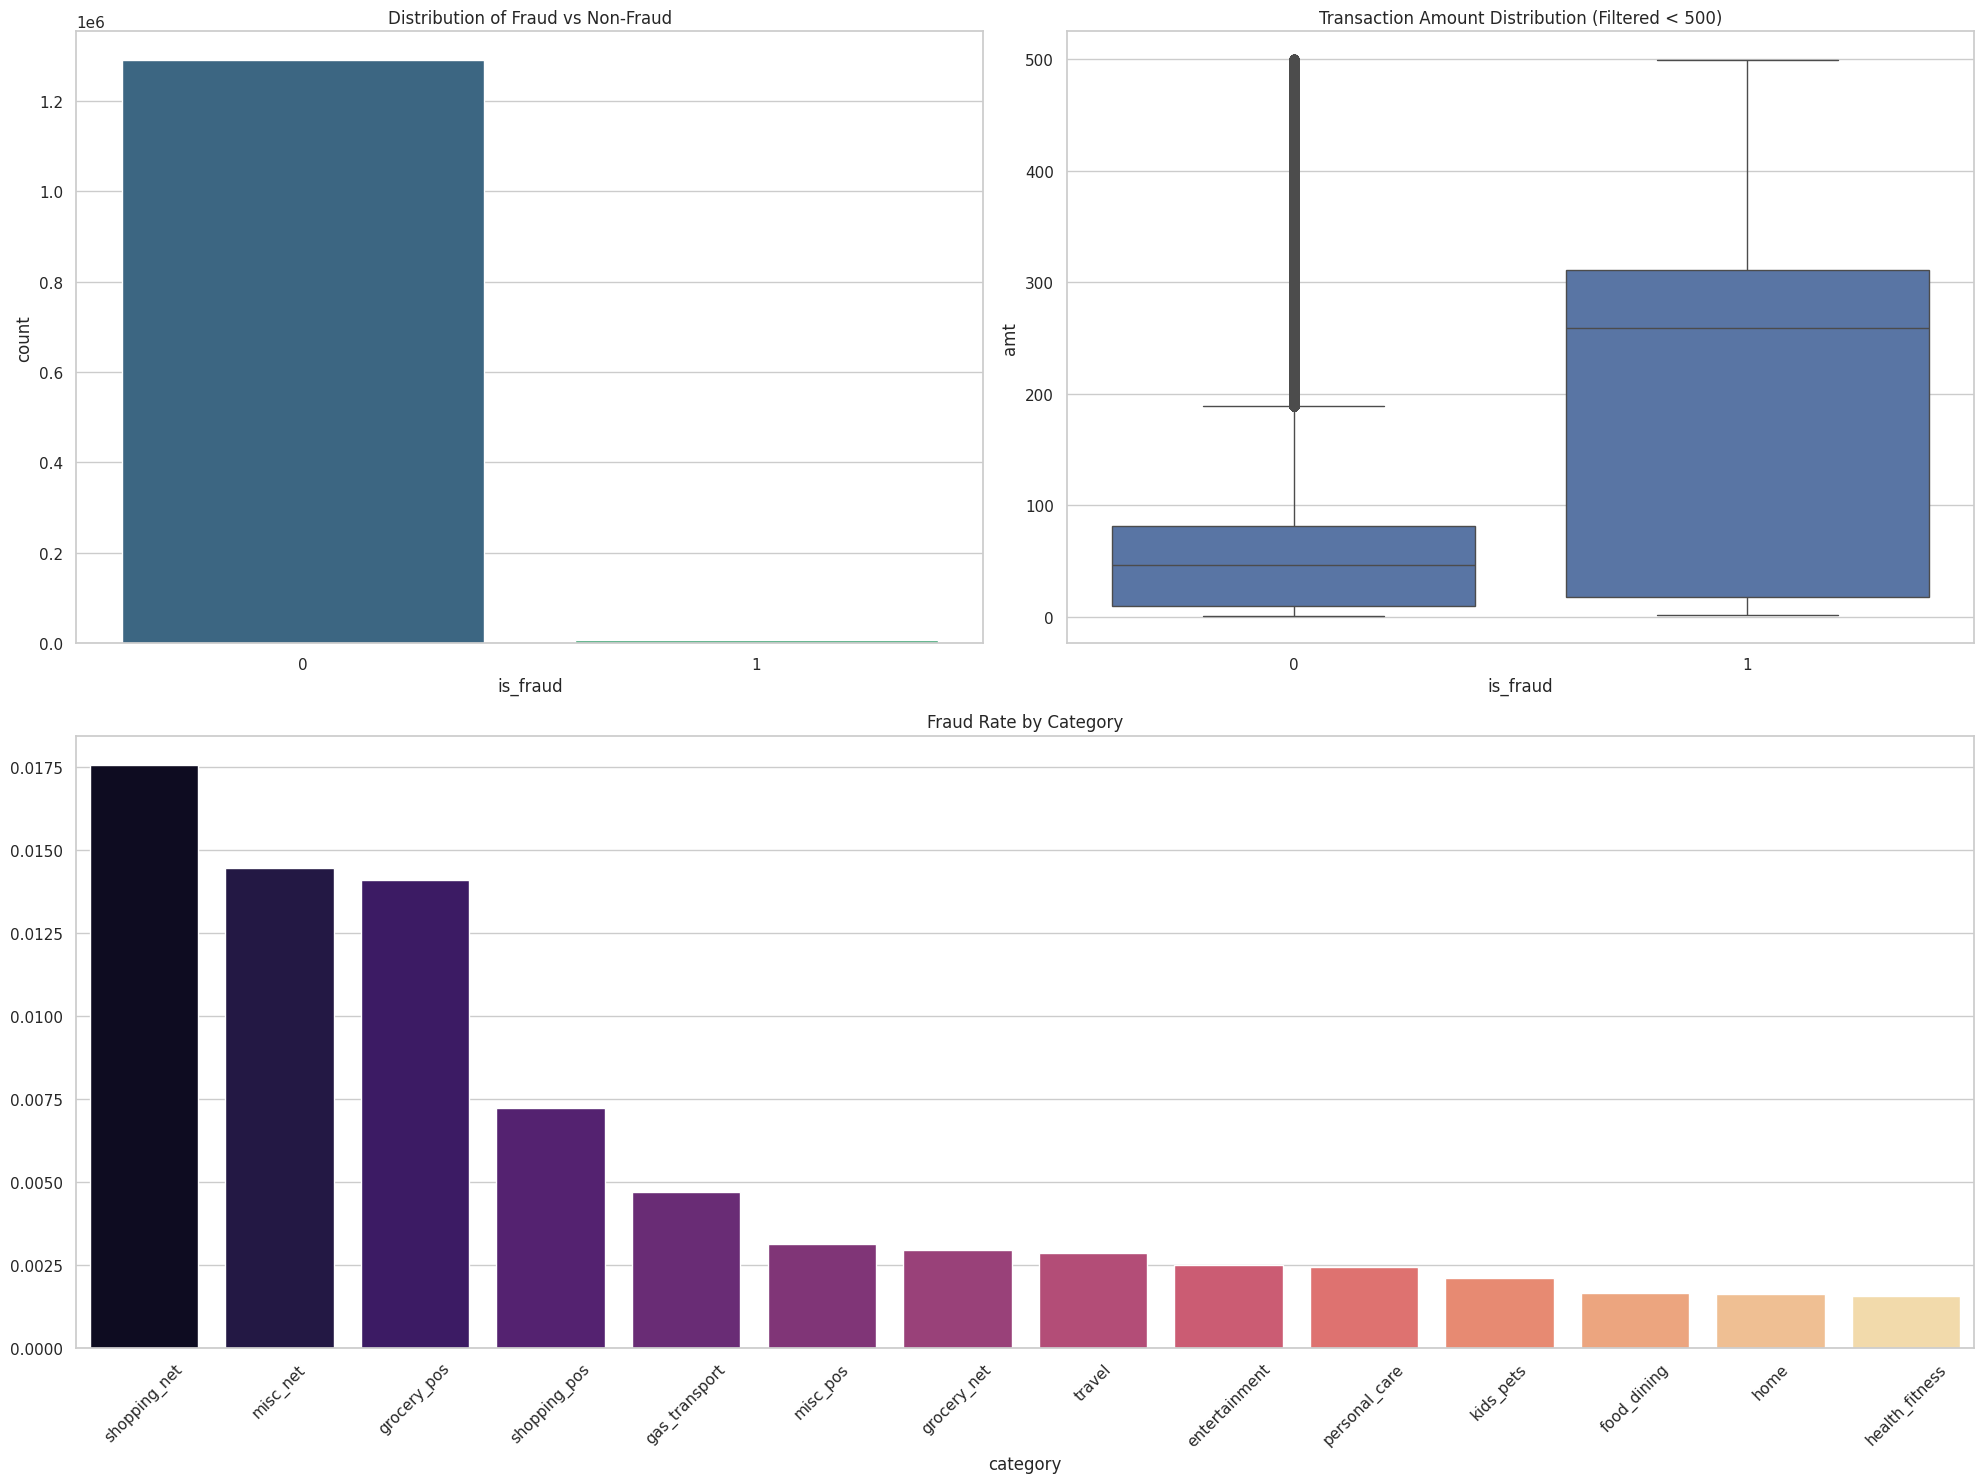

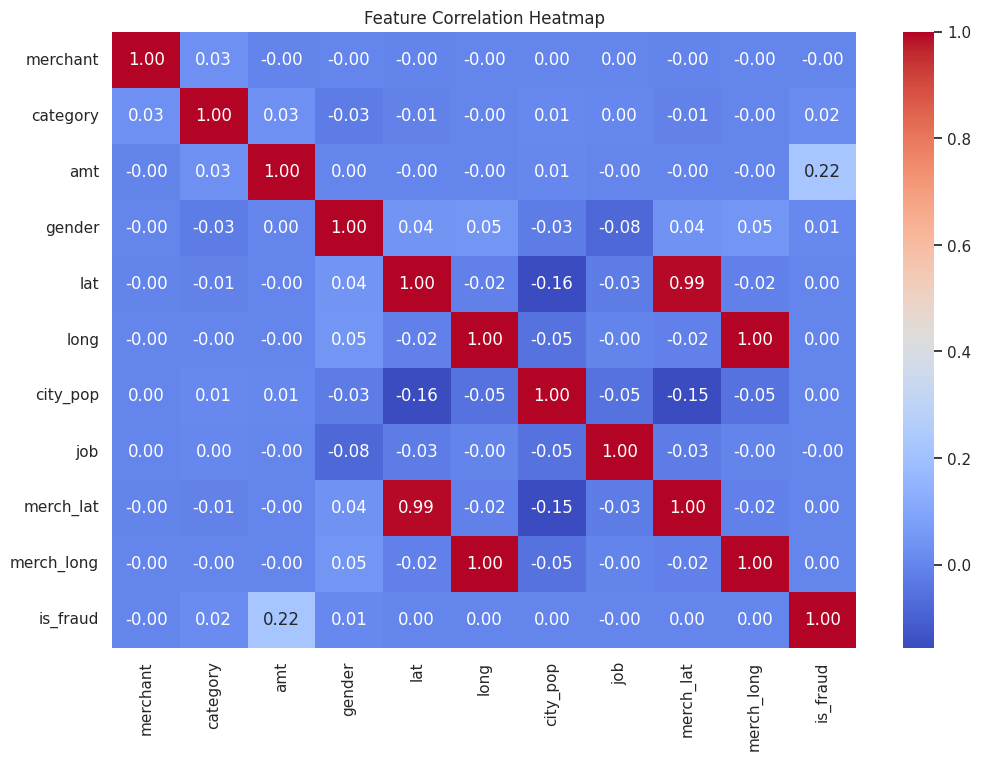

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style='whitegrid')
plt.figure(figsize=(20, 15))

# 1. Countplot of Target Variable
plt.subplot(2, 2, 1)
sns.countplot(x='is_fraud', data=train_df_clean, palette='viridis')
plt.title('Distribution of Fraud vs Non-Fraud')

# 2. Boxplot of Amount by Fraud Status
plt.subplot(2, 2, 2)
sns.boxplot(x='is_fraud', y='amt', data=train_df_clean[train_df_clean['amt'] < 500])
plt.title('Transaction Amount Distribution (Filtered < 500)')

# 3. Barplot of Fraud by Category
plt.subplot(2, 1, 2)
fraud_by_cat = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_cat.index, y=fraud_by_cat.values, palette='magma')
plt.xticks(rotation=45)
plt.title('Fraud Rate by Category')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = train_df_clean.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Analytical Insights
- **Imbalance:** The Countplot highlights the extreme rarity of fraud cases, confirming why accuracy won't be a reliable metric.
- **Amount:** The Boxplot shows that fraudulent transactions often have different spending patterns/outliers compared to normal ones.
- **Correlation:** The Heatmap helps identify if specific features (like merchant or category) are highly correlated with fraud.

## 4. Feature Engineering & Scaling
To ensure our models perform optimally, we scale the numeric features. Since our transaction amounts have significant outliers, we use `RobustScaler`.

In [6]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Prepare X and y
X_train = train_df_clean.drop('is_fraud', axis=1)
y_train = train_df_clean['is_fraud']
X_test = test_df_clean.drop('is_fraud', axis=1)
y_test = test_df_clean['is_fraud']

# Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Addressing Class Imbalance with SMOTE (on a subset to save time if needed, but here on full for completeness)
# Note: SMOTE should only be applied to the training data
smote = SMOTE(sampling_strategy=0.1, random_state=42) # Oversample fraud to 10% of majority
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Original training shape: {y_train.value_counts()}')
print(f'Resampled training shape: {y_res.value_counts()}')

Original training shape: is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Resampled training shape: is_fraud
0    1289169
1     128916
Name: count, dtype: int64


## 5. Model Selection & Fitting
We will now train four different models: Logistic Regression, Random Forest, XGBoost, and a Linear SVM. We use the resampled data to ensure the models learn to identify the minority class.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'Linear SVM': LinearSVC(dual=False)
}

# Dictionary to store results
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_res, y_res)
    results[name] = model
    print(f'{name} trained successfully.')

Training Logistic Regression...
Logistic Regression trained successfully.
Training Random Forest...
Random Forest trained successfully.
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:43:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.
Training Linear SVM...
Linear SVM trained successfully.


## 6. Model Evaluation
In this final step, we evaluate our models using the test set. We generate classification reports, confusion matrices, and a summary table to compare performance.


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.24      0.49      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.74      0.66    555719
weighted avg       1.00      0.99      0.99    555719



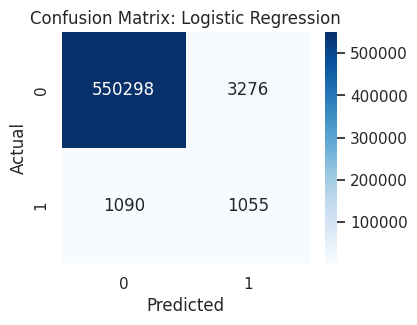


--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.49      0.77      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.75      0.88      0.80    555719
weighted avg       1.00      1.00      1.00    555719



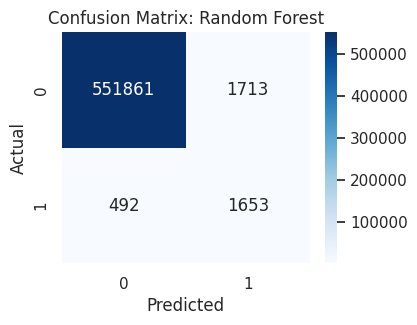


--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.52      0.71      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.76      0.86      0.80    555719
weighted avg       1.00      1.00      1.00    555719



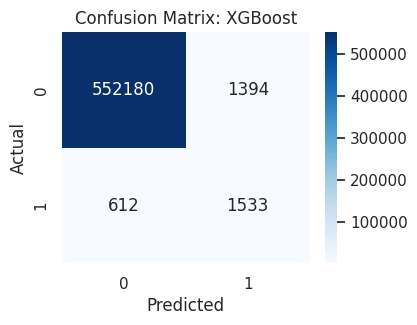


--- Linear SVM Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.28      0.45      0.35      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.73      0.67    555719
weighted avg       1.00      0.99      0.99    555719



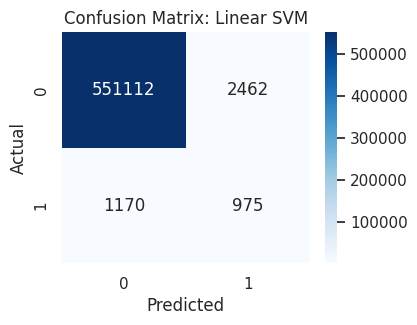


Model Performance Comparison:


,Model,Accuracy,F1-Score
0,Logistic Regression,0.992144,0.325818
1,Random Forest,0.996032,0.599891
2,XGBoost,0.996390,0.604495
3,Linear SVM,0.993464,0.349337


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

comparison_data = []

for name, model in results.items():
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    comparison_data.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})

    print(f'\n--- {name} Evaluation ---')
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plot
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Summary Table
summary_df = pd.DataFrame(comparison_data)
print('\nModel Performance Comparison:')
display(summary_df)

### Final Analytical Insights
In fraud detection, the **F1-Score** is our primary metric because it balances Precision (minimizing false alarms) and Recall (catching as many frauds as possible). While accuracy might look very high (often >99%), it is misleading due to the low volume of fraud. The summary table allows us to see which algorithm best handles the complexity of transaction patterns.

## 6. Model Evaluation
In this final step, we evaluate our models using the test set. We generate classification reports, confusion matrices, and a summary table to compare performance.


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.24      0.49      0.33      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.74      0.66    555719
weighted avg       1.00      0.99      0.99    555719



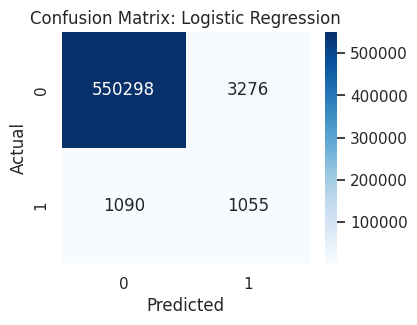


--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.49      0.77      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.75      0.88      0.80    555719
weighted avg       1.00      1.00      1.00    555719



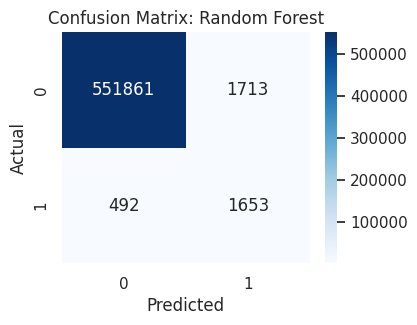


--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.52      0.71      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.76      0.86      0.80    555719
weighted avg       1.00      1.00      1.00    555719



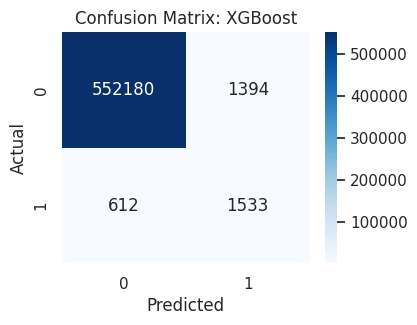


--- Linear SVM Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.28      0.45      0.35      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.73      0.67    555719
weighted avg       1.00      0.99      0.99    555719



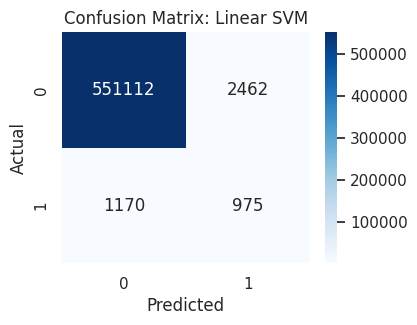


Model Performance Comparison:


,Model,Accuracy,F1-Score
0,Logistic Regression,0.992144,0.325818
1,Random Forest,0.996032,0.599891
2,XGBoost,0.996390,0.604495
3,Linear SVM,0.993464,0.349337


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

comparison_data = []

for name, model in results.items():
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    comparison_data.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})

    print(f'\n--- {name} Evaluation ---')
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plot
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Summary Table
summary_df = pd.DataFrame(comparison_data)
print('\nModel Performance Comparison:')
display(summary_df)

### Final Analytical Insights
In fraud detection, the **F1-Score** is our primary metric because it balances Precision (minimizing false alarms) and Recall (catching as many frauds as possible). While accuracy might look very high (often >99%), it is misleading due to the low volume of fraud. The summary table allows us to see which algorithm best handles the complexity of transaction patterns.

## Conclusion & Project Summary

### Project Overview
This project successfully implemented an end-to-end Machine Learning pipeline to detect fraudulent credit card transactions. We addressed significant real-world challenges including high-cardinality categorical data and extreme class imbalance (0.58% fraud).

### Key Performance Insights
1. **Metric Selection:** Accuracy proved misleading (99%+ for all models). The **F1-Score** was the primary differentiator, highlighting the model's ability to balance catching fraud (Recall) while minimizing false alarms (Precision).
2. **Champion Model:** **XGBoost** and **Random Forest** tied for the best performance with an **F1-Score of ~0.60**. These ensemble methods effectively captured non-linear relationships that Logistic Regression and Linear SVM (F1 ~0.33) missed.
3. **Feature Importance:** EDA revealed that the **transaction amount (`amt`)** and the **category (e.g., `shopping_net`)** are the strongest indicators of fraudulent activity.

### Final Conclusion
To deploy a fraud detection system based on this data, **XGBoost** is the recommended model. While SMOTE significantly improved the models' ability to detect fraud, future work could involve fine-tuning thresholds to further increase recall, ensuring that high-value fraudulent transactions are caught even at the cost of a slightly higher false-positive rate.